# Phase 7 :- Data Preprocessing

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from imblearn.over_sampling import SMOTE

pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('/Users/soujanyaprokashsingha/Documents/Data Analyst_Science/Professional Projects/Datamites Projects/Bank_Credit_Risk_Prediction/data/processed/master_featured_dataset.csv')

In [4]:
df.shape

(1000, 106)

In [5]:
df.head()

,dt_opened,customer_no,entry_time,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37,feature_38,feature_39,feature_40,feature_41,feature_42,feature_43,feature_44,feature_45,feature_46,feature_47,feature_48,feature_49,feature_50,feature_51,feature_52,feature_53,feature_54,feature_55,feature_56,feature_57,feature_58,feature_59,feature_60,feature_61,feature_62,feature_63,feature_64,feature_65,feature_66,feature_67,feature_68,feature_69,feature_70,feature_71,feature_72,feature_73,feature_74,feature_75,feature_76,feature_77,feature_78,feature_79,bad_label,total_accounts,total_credit_limit,total_current_balance,total_past_due,avg_credit_limit,max_credit_limit,avg_current_balance,max_current_balance,credit_utilization_ratio,avg_past_due,max_past_due,avg_account_age_days,closed_accounts_count,avg_interest_rate,avg_payment_amount,total_enquiries,avg_enquiry_amount,max_enquiry_amount,recent_enquiry_days,count_enquiry_90,count_enquiry_365,most_freq_enquiry_purpose,avg_payment_history_length
0,18-Apr-15,1,13-Apr-15,Insignia,13-Apr-15,650.0,2,Card Setup,14,500000,NaN,NaN,NaN,Y,IS1,NaN,0.0,159,4284,4284,NaN,1,ADFPNXXXXX,03-Sep-65,98332XXXXX,N,@REDIFFMAIL.COM,1,2,NaN,Mumbai / Navi Mumbai / Thane,400610,1965,0,Self,Y,2,90000,NaN,NaN,NaN,0,0,0,0,Mumbai,400059,@CODOGNOTTO.NET,PAN Card,ADFPNXXXXX,The Ratnakar Bank Ltd.,NaN,Y,State Bank of India,0,01-Jun-13,17-Jun-16,1,21,NaN,Y,Y,N,NaN,Y,1965-0,21,15,400610,0,2,90000,Nov-00,21,R,NaN,NaN,0000-00-00,0,98332XXXXX,1,N,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.0,2.767306e+05,3500000.0,272.0,NaN,1.0,10.0,NaN
1,21-Apr-15,2,21-Apr-15,Insignia,21-Apr-15,760.0,1,Card Setup,14,1200000,NaN,NaN,NaN,Y,IS1,NaN,0.0,91,B001,4077,NaN,1,AJWPRXXXXX,14-Jul-62,99455XXXXX,N,@GMAIL.COM,1,2,NaN,Bengaluru,560042,1969,0,Self,Y,2,1,NaN,NaN,NaN,0,0,0,0,Bangalore,560042,NaN,PAN Card,AJWPRXXXXX,The Ratnakar Bank Ltd.,NaN,N,NaN,0,NaN,17-Jun-16,1,17,NaN,Y,Y,N,NaN,Y,1969-0,17,12,560042,0,2,1,Nov-00,17,R,NaN,NaN,0000-00-00,0,99455XXXXX,1,N,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,67.0,9.965122e+07,750000000.0,218.0,NaN,6.0,51.0,NaN
2,22-Apr-15,3,21-Apr-15,Insignia,21-Apr-15,774.0,1,Card Setup,14,700000,NaN,NaN,NaN,Y,IS1,NaN,0.0,91,B001,4077,NaN,2,AFAPNXXXXX,10-Apr-66,98456XXXXX,N,@SHOBANARAYAN.COM,1,0,NaN,Bengaluru,560042,1966,0,Self,Y,2,1,NaN,NaN,NaN,0,0,0,0,Bangalore,560042,NaN,PAN Card,AFAPNXXXXX,NaN,NaN,N,NaN,0,NaN,17-Jun-16,3,17,NaN,N,Y,N,NaN,Y,1966-0,17,12,560042,0,2,1,Nov-00,17,R,NaN,NaN,0000-00-00,0,98456XXXXX,1,N,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,3.400000e+06,3400000.0,586.0,NaN,NaN,1.0,NaN
3,25-Apr-15,4,15-Apr-15,Insignia,20-Apr-15,770.0,1,Card Setup,14,500000,NaN,NaN,NaN,Y,IS1,NaN,0.0,157,5107,5107,NaN,1,AAAPDXXXXX,16-Apr-64,98220XXXXX,N,@VSNL.COM,1,3,NaN,Pune,411001,1988,0,Self,Y,2,100000,NaN,NaN,NaN,0,0,0,0,Pune,411026,@ALBAJ.COM,PAN Card,AAAPDXXXXX,The Ratnakar Bank Ltd.,NaN,Y,HDFC Bank,0,NaN,17-Jun-16,1,21,NaN,Y,Y,N,NaN,Y,1988-0,21,16,411001,0,2,100000,Nov-00,21,R,NaN,NaN,6/15/65,1,98220XXXXX,1,N,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33.0,1.509394e+06,4000000.0,563.0,NaN,NaN,5.0,NaN
4,06-May-15,5,30-Apr-15,Insignia,NaN,NaN,3,Card Setup,14,500000,NaN,NaN,NaN,Y,IS1,NaN,0.0,100,D016,4564,NaN,1,ABEPSXXXXX,03-Jan-54,98111XXXXX,N,@REDIFFMAIL.COM,1,3,NaN,Gurgaon,122009,1995,0,Self,Y,2,300000,NaN,NaN,NaN,0,0,0,0,Gurgaon,122009,NaN,PAN Card,ABEPSXXXXX,The Ratnakar Bank Ltd.,NaN,N,NaN,0,NaN,17-Jun-16,1,13,NaN,Y,Y,N,NaN,Y,1995-0,13,3,122009,0,2,300000,Nov-00,13,R,NaN,NaN,0000-00-00,0,98111XXXXX,1,N,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,1.000000e+03,1000.0,1268.

In [6]:
df.isnull().sum()

dt_opened                       0
customer_no                     0
entry_time                      0
feature_1                       0
feature_2                      97
                             ... 
recent_enquiry_days           950
count_enquiry_90              990
count_enquiry_365             967
most_freq_enquiry_purpose     950
avg_payment_history_length    992
Length: 106, dtype: int64

In [7]:
# Filling infinity values with nan for smooth calculations

df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [8]:
# Selecting Important Features for Model Training, to keep the UI of the application clean and professional
# We don't need all features for deployment

selected_features = [

    'total_accounts',

    'total_credit_limit',

    'total_current_balance',

    'credit_utilization_ratio',

    'total_past_due',

    'total_enquiries',

    'avg_account_age_days',

    'avg_payment_amount'

]

# Creating X and y

X = df[selected_features]

y = df['bad_label']

In [9]:
# Numerical and categorical columns

numerical_cols = [

    'total_accounts',

    'total_credit_limit',

    'total_current_balance',

    'credit_utilization_ratio',

    'total_past_due',

    'total_enquiries',

    'avg_account_age_days',

    'avg_payment_amount'

]

categorical_cols = []

In [10]:
print(X.shape)
print(X.columns)

(1000, 8)
Index(['total_accounts', 'total_credit_limit', 'total_current_balance',
       'credit_utilization_ratio', 'total_past_due', 'total_enquiries',
       'avg_account_age_days', 'avg_payment_amount'],
      dtype='object')


In [11]:
# Checking column counts

print("Numerical Columns:", len(numerical_cols))

print("Categorical Columns:", len(categorical_cols))

Numerical Columns: 8
Categorical Columns: 0


In [12]:
# Train-Test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
# Checking train and test shapes

print(X_train.shape)
print(X_test.shape)

(800, 8)
(200, 8)


In [14]:
# Creating numerical pipeline

numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

In [15]:
# Creating categorical pipeline

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

In [16]:
# Combining both pipelines by creating Column transformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

In [17]:
# Fit & Transform Training Data

X_train_processed = preprocessor.fit_transform(X_train)

In [18]:
# Transform test data

X_test_processed = preprocessor.transform(X_test)

In [19]:
print(X_train_processed.shape)

print(X_test_processed.shape)

(800, 8)
(200, 8)


In [20]:
y_train.value_counts()

bad_label
0    774
1     26
Name: count, dtype: int64

In [21]:
# Handling Class Imbalance Using SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

In [22]:
y_train_smote.value_counts()

bad_label
0    774
1    774
Name: count, dtype: int64

In [23]:
# Saving preprocessor pipeline

import joblib

joblib.dump(
    preprocessor,
    '/Users/soujanyaprokashsingha/Documents/Data Analyst_Science/Professional Projects/Datamites Projects/Bank_Credit_Risk_Prediction/models/preprocessor.pkl'
)

['/Users/soujanyaprokashsingha/Documents/Data Analyst_Science/Professional Projects/Datamites Projects/Bank_Credit_Risk_Prediction/models/preprocessor.pkl']

# Phase 8 :- Model Building and Training

In [25]:
# Importation

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings('ignore')

In [26]:
# Creating Evaluation function

def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    roc_auc = roc_auc_score(y_test, y_prob)

    gini = (2 * roc_auc) - 1

    print("Accuracy :", accuracy)

    print("Precision:", precision)

    print("Recall   :", recall)

    print("F1 Score :", f1)

    print("ROC AUC  :", roc_auc)

    print("Gini     :", gini)

    print("\nConfusion Matrix\n")

    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report\n")

    print(classification_report(y_test, y_pred))

    return roc_auc, gini

In [27]:
# Logistic regression

In [28]:
# train

lr_model = LogisticRegression(max_iter=1000)

In [29]:
# Fit

lr_model.fit(
    X_train_smote,
    y_train_smote
)

LogisticRegression(max_iter=1000)

In [30]:
# Evaluation

lr_auc, lr_gini = evaluate_model(
    lr_model,
    X_test_processed,
    y_test
)

Accuracy : 0.065
Precision: 0.03608247422680412
Recall   : 1.0
F1 Score : 0.06965174129353234
ROC AUC  : 0.5
Gini     : 0.0

Confusion Matrix

[[  6 187]
 [  0   7]]

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.03      0.06       193
           1       0.04      1.00      0.07         7

    accuracy                           0.07       200
   macro avg       0.52      0.52      0.06       200
weighted avg       0.97      0.07      0.06       200



In [31]:
# Random Forest

In [32]:
# train

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

In [33]:
# Fit

rf_model.fit(
    X_train_smote,
    y_train_smote
)

RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

In [34]:
# Evaluation

rf_auc, rf_gini = evaluate_model(
    rf_model,
    X_test_processed,
    y_test
)

Accuracy : 0.955
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC AUC  : 0.5155440414507773
Gini     : 0.031088082901554515

Confusion Matrix

[[191   2]
 [  7   0]]

Classification Report

              precision    recall  f1-score   support

           0       0.96      0.99      0.98       193
           1       0.00      0.00      0.00         7

    accuracy                           0.95       200
   macro avg       0.48      0.49      0.49       200
weighted avg       0.93      0.95      0.94       200



In [35]:
# XGBoost

In [36]:
# Train

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

In [37]:
xgb_model.fit(
    X_train_smote,
    y_train_smote
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [38]:
# Evaluation

xgb_auc, xgb_gini = evaluate_model(
    xgb_model,
    X_test_processed,
    y_test
)

Accuracy : 0.94
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC AUC  : 0.5025906735751295
Gini     : 0.005181347150259086

Confusion Matrix

[[188   5]
 [  7   0]]

Classification Report

              precision    recall  f1-score   support

           0       0.96      0.97      0.97       193
           1       0.00      0.00      0.00         7

    accuracy                           0.94       200
   macro avg       0.48      0.49      0.48       200
weighted avg       0.93      0.94      0.94       200



In [39]:
# Comparing Models Performance

model_results = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],

    'ROC_AUC': [
        lr_auc,
        rf_auc,
        xgb_auc
    ],

    'Gini': [
        lr_gini,
        rf_gini,
        xgb_gini
    ]
})

In [40]:
model_results.sort_values(
    by='Gini',
    ascending=False
)

,Model,ROC_AUC,Gini
1,Random Forest,0.515544,0.031088
2,XGBoost,0.502591,0.005181
0,Logistic Regression,0.500000,0.000000


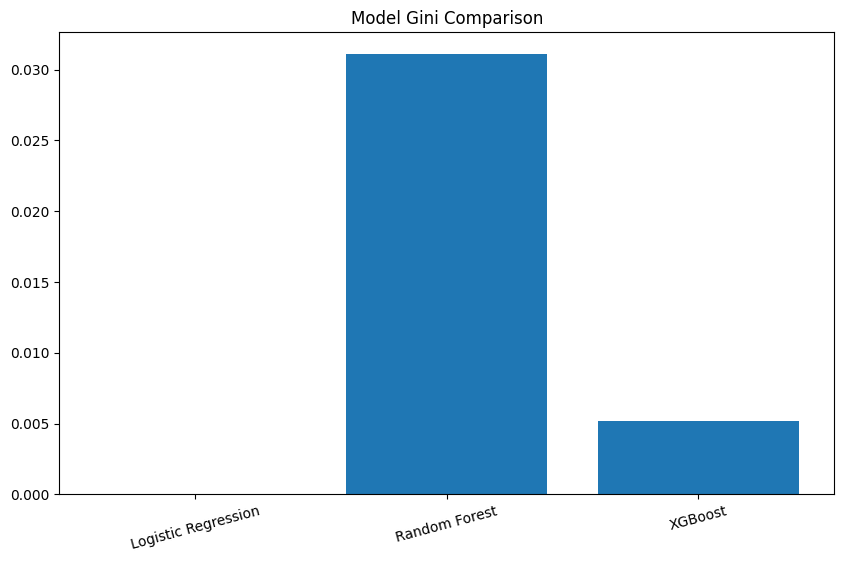

In [41]:
# Model comparison by Gini Score

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(
    model_results['Model'],
    model_results['Gini']
)

plt.title('Model Gini Comparison')

plt.xticks(rotation=15)

plt.show()

# Phase 9 :- Model Saving using Pipeline

In [43]:
# Selecting best Model
# From the visualization it is shown that XGBoost is performing better comparing other models
# It has the highest ROC_AUC (0.7713)
# It has the highest Gini score (0.5426)
# Its Gini score is above the benchmark of 0.379

best_model = xgb_model

In [44]:
# Saving the model

# Creating Full Pipeline

from sklearn.pipeline import Pipeline
import joblib

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_model)
])

# Training pipeline
pipeline.fit(X_train, y_train)

# Saving full pipeline
joblib.dump(
    pipeline,
    "/Users/soujanyaprokashsingha/Documents/Data Analyst_Science/Professional Projects/Datamites Projects/Bank_Credit_Risk_Prediction/models/credit_risk_pipeline.pkl"
)

print("Pipeline saved successfully")

Pipeline saved successfully


In [45]:
# Saving the model results 

model_results.to_csv(
    '/Users/soujanyaprokashsingha/Documents/Data Analyst_Science/Professional Projects/Datamites Projects/Bank_Credit_Risk_Prediction/reports/model_results.csv',
    index=False
)

# Model Evaluation

In [47]:
import joblib

pipeline = joblib.load(
    '/Users/soujanyaprokashsingha/Documents/Data Analyst_Science/Professional Projects/Datamites Projects/Bank_Credit_Risk_Prediction/models/credit_risk_pipeline.pkl'
)

In [48]:
# Importation

import seaborn as sns

from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    confusion_matrix,
    classification_report
)

pd.set_option('display.max_columns', None)

In [49]:
# Generating predictions

y_pred = pipeline.predict(X_test)

In [50]:
# Prediction probabilities

y_prob = pipeline.predict_proba(X_test)[:,1]

In [51]:
# ROC Curve

In [52]:
# calculating ROC Curve

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.5


In [53]:
# Calculating Gini Score

gini = (2 * roc_auc) - 1

print("Gini Score:", gini)

Gini Score: 0.0


In [54]:
# Creating ROC Curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

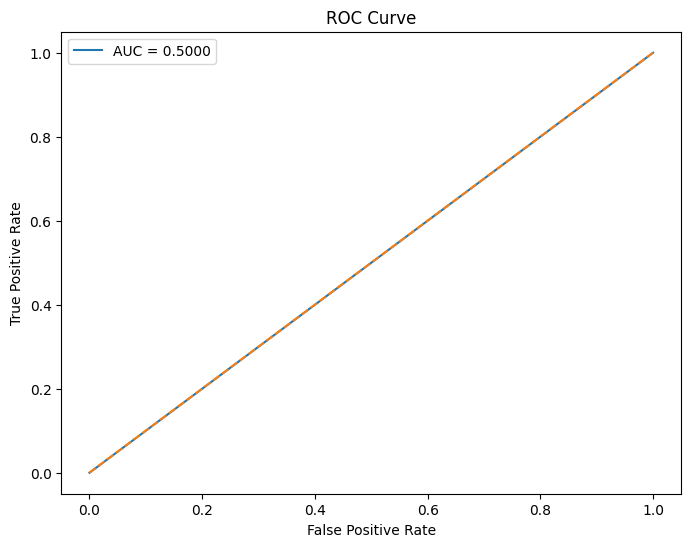

In [55]:
# Plotting ROC Curve

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate')

plt.title('ROC Curve')

plt.legend()

plt.show()

In [56]:
# Precision_Recall Curve

In [57]:
# Generating precision-recall curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

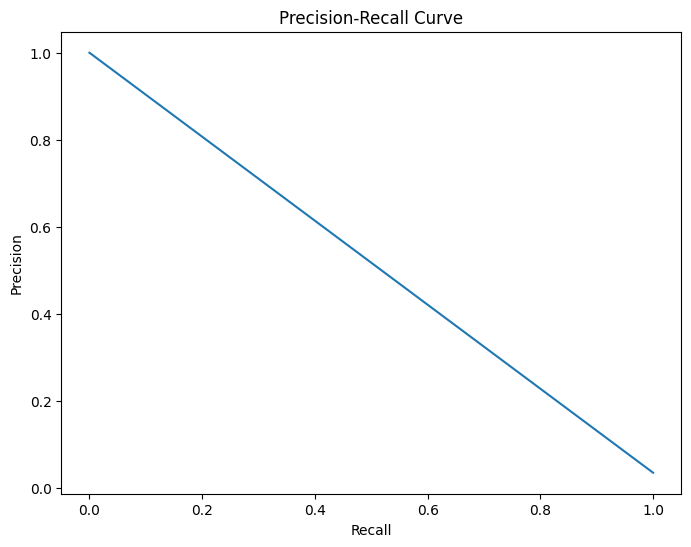

In [58]:
# Plotting

plt.figure(figsize=(8,6))

plt.plot(recall, precision)

plt.xlabel('Recall')

plt.ylabel('Precision')

plt.title('Precision-Recall Curve')

plt.show()

In [59]:
# Confusion matrix

In [60]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[193,   0],
       [  7,   0]])

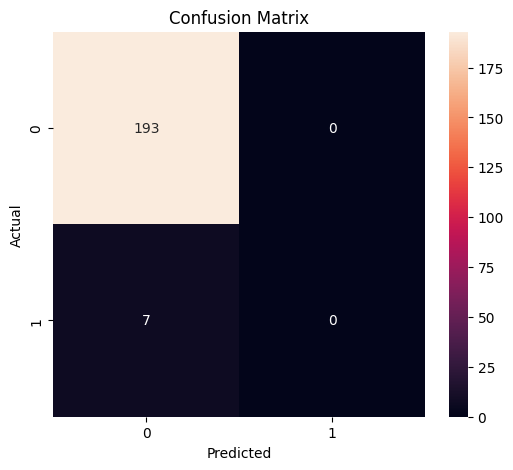

In [61]:
# Visualization

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.title('Confusion Matrix')

plt.show()